Estratégia:

Fonte dos Dados: Ignorar os arquivos de treino e validação originais por conterem apenas dados não-anômalos. Usaremos o arquivo labelled_testing_data.csv como nossa única fonte de dados, pois é o único que contém ambas as classes (benigno e malicioso).

Nova Divisão de Dados: Dividiremos este arquivo em um novo conjunto de treino (80%) e um novo conjunto de teste (20%). Desta forma, teremos anomalias em ambos os conjuntos para treinar e avaliar o modelo.

Balanceamento de Classes: O novo conjunto de treino ainda será extremamente desbalanceado. Portanto, aplicaremos a técnica SMOTE para criar um conjunto de treino final balanceado, assim como foi feito no dataset anterior.

Engenharia de Features e Modelagem: Seguiremos com o RandomForestClassifier e aplicaremos as etapas de engenharia de features que planejamos.

In [1]:
# --- Importações Essenciais ---
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

# --- Importações do Scikit-learn e Imbalanced-learn ---
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from imblearn.over_sampling import SMOTE
from sklearn.metrics import f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, precision_recall_curve, auc
from tqdm.notebook import tqdm # Para barras de progresso visuais

# --- Configurações de Visualização ---
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (16, 8)
pd.set_option('display.max_columns', 50)

print("Bibliotecas importadas e configurações aplicadas.")

Bibliotecas importadas e configurações aplicadas.


In [2]:
# --- Definição dos Caminhos ---
# O notebook está em: log-anomaly-detection-ml/notebooks/BETH-Cybersecurity-Logs/
data_path = '../../data/raw/BETH'
source_filename = 'labelled_testing_data.csv'
full_path = os.path.join(data_path, source_filename)

# --- Carregamento do Dataset ---
# Usaremos apenas o arquivo de teste original, pois é o único com ambas as classes.
try:
    df = pd.read_csv(full_path)
    print("Dataset carregado com sucesso!")
    print(f"Formato: {df.shape[0]} linhas, {df.shape[1]} colunas")
except FileNotFoundError:
    print(f"Erro: Arquivo não encontrado em {os.path.abspath(full_path)}")

# --- Preparação da Variável Alvo ---
df['out'] = df['evil']
# As colunas 'sus' e 'eventId' também são removidas para evitar vazamento de informação do evento
df.drop(columns=['sus', 'evil', 'eventId'], inplace=True)

# --- Divisão em Treino e Teste Finais ---
# Dividiremos em um conjunto de treino (80%) para tuning e um conjunto de teste final (20%)
X = df.drop('out', axis=1)
y = df['out']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42,
    stratify=y  # Essencial para manter a proporção de anomalias
)

print("\nDivisão de dados em Treino e Teste concluída:")
print(f"Treino (X, y): \t{X_train.shape}, {y_train.shape}")
print(f"Teste (X, y):  \t{X_test.shape}, {y_test.shape}")

Dataset carregado com sucesso!
Formato: 188967 linhas, 16 colunas

Divisão de dados em Treino e Teste concluída:
Treino (X, y): 	(151173, 13), (151173,)
Teste (X, y):  	(37794, 13), (37794,)


In [3]:
# --- Engenharia de Features (Pré-Pipeline) ---
def create_time_features(data):
    df = data.copy()
    # Garantir a ordenação correta para o cálculo da diferença de tempo
    df = df.sort_values(by=['hostName', 'timestamp'])
    # Calcular a diferença de tempo para o evento anterior no mesmo host
    df['time_diff'] = df.groupby('hostName')['timestamp'].diff().fillna(0)
    return df

print("Aplicando engenharia de features de tempo...")
X_train = create_time_features(X_train)
X_test = create_time_features(X_test)
print("Engenharia de features de tempo concluída.")

# --- Definição e Aplicação do Pré-processador ---
numeric_features = ['timestamp', 'processId', 'threadId', 'parentProcessId', 'userId', 'argsNum', 'returnValue', 'time_diff']
categorical_features = ['processName', 'hostName', 'eventName']
drop_features = ['mountNamespace', 'stackAddresses', 'args']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', max_categories=25, sparse_output=False), categorical_features),
        ('drop', 'drop', drop_features)
    ],
    remainder='passthrough'
)

print("\nAplicando o pré-processador aos dados...")
# Treinar o pré-processador APENAS nos dados de treino
X_train_proc = preprocessor.fit_transform(X_train)
# Transformar o teste com o pré-processador já treinado
X_test_proc = preprocessor.transform(X_test)

print(f"Formato dos dados após pré-processamento:")
print(f"Treino: \t{X_train_proc.shape}")
print(f"Teste:  \t{X_test_proc.shape}")

Aplicando engenharia de features de tempo...
Engenharia de features de tempo concluída.

Aplicando o pré-processador aos dados...
Formato dos dados após pré-processamento:
Treino: 	(151173, 59)
Teste:  	(37794, 59)


In [4]:
# --- Definição da Grade e Preparação ---
param_grid = {
    'n_estimators': [150, 250],
    'max_depth': [20, None],
    'min_samples_leaf': [1, 5, 50],
    'class_weight': [None]
}
results_list = []
n_splits = 5 # Usaremos 3 folds para a validação cruzada
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

print(f"Iniciando busca manual com validação cruzada de {n_splits} folds...")

# --- Loop Externo: Hiperparâmetros ---
# A função product gera todas as combinações possíveis
from itertools import product
param_combinations = list(product(*param_grid.values()))

for params in tqdm(param_combinations, desc="Combinações de Hiperparâmetros"):
    n_est, m_depth, m_leaf, c_weight = params
    fold_scores = []
    
    # --- Loop Interno: Folds de Validação Cruzada ---
    for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_proc, y_train)):
        
        # 1. Dividir os dados para este fold
        X_train_fold, X_val_fold = X_train_proc[train_idx], X_train_proc[val_idx]
        y_train_fold, y_val_fold = y_train.iloc[train_idx], y_train.iloc[val_idx]

        # 2. Aplicar SMOTE APENAS na porção de treino deste fold
        smote = SMOTE(random_state=None, sampling_strategy='not majority')
        X_train_fold_res, y_train_fold_res = smote.fit_resample(X_train_fold, y_train_fold)
        
        # 3. Treinar o modelo
        model = RandomForestClassifier(
            n_estimators=n_est, max_depth=m_depth, min_samples_leaf=m_leaf,
            class_weight=c_weight, random_state=None, n_jobs=-1
        )
        model.fit(X_train_fold_res, y_train_fold_res)
        
        # 4. Avaliar no conjunto de validação do fold (sem SMOTE)
        y_pred_fold = model.predict(X_val_fold)
        fold_scores.append(f1_score(y_val_fold, y_pred_fold, pos_label=1))

    # Calcular a média dos scores dos folds
    avg_score = np.mean(fold_scores)
    
    results_list.append({
        'n_estimators': n_est, 'max_depth': m_depth, 'min_samples_leaf': m_leaf,
        'class_weight': c_weight, 'f1_malicious_cv': avg_score
    })

print("\nBusca manual concluída!")

Iniciando busca manual com validação cruzada de 5 folds...


Combinações de Hiperparâmetros:   0%|          | 0/12 [00:00<?, ?it/s]


Busca manual concluída!


In [5]:
# --- Análise dos Resultados ---
results_df = pd.DataFrame(results_list)
best_params_row = results_df.sort_values(by='f1_malicious_cv', ascending=False).iloc[0]
best_params = best_params_row.to_dict()
best_params.pop('f1_malicious_cv')

print("--- Melhores parâmetros encontrados (média da validação cruzada) ---")
print(best_params)

# Corrigir o valor de max_depth se ele for nan
if pd.isna(best_params.get('max_depth')):
    best_params['max_depth'] = None
else:
    best_params['max_depth'] = int(best_params['max_depth'])
best_params['n_estimators'] = int(best_params['n_estimators'])
best_params['min_samples_leaf'] = int(best_params['min_samples_leaf'])

# --- Treino do Modelo Final ---
# Usamos o conjunto de treino completo (sem CV) e aplicamos SMOTE
print("\nBalanceando o conjunto de treino completo com SMOTE para o modelo final...")
smote_final = SMOTE(random_state=None, sampling_strategy='not majority')
X_train_final_resampled, y_train_final_resampled = smote_final.fit_resample(X_train_proc, y_train)

print("\nTreinando o modelo final...")
final_model = RandomForestClassifier(**best_params, random_state=None, n_jobs=-1)
final_model.fit(X_train_final_resampled, y_train_final_resampled)
print("Treino final concluído.")

--- Melhores parâmetros encontrados (média da validação cruzada) ---
{'n_estimators': 250, 'max_depth': nan, 'min_samples_leaf': 5, 'class_weight': None}

Balanceando o conjunto de treino completo com SMOTE para o modelo final...

Treinando o modelo final...
Treino final concluído.


Avaliando no conjunto de teste...
Melhor Limiar de Decisão encontrado no teste: 0.1620

--- Relatório de Classificação Final (com Limiar Otimizado) ---
               precision    recall  f1-score   support

  Benigno (0)       0.00      0.00      0.00      6107
Malicioso (1)       0.84      1.00      0.91     31687

     accuracy                           0.84     37794
    macro avg       0.42      0.50      0.46     37794
 weighted avg       0.70      0.84      0.76     37794


ROC AUC (Teste): 0.4979

--- Matriz de Confusão Final ---


C:\Users\GabrielMoreira\log-anomaly-detection-ml\venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\GabrielMoreira\log-anomaly-detection-ml\venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\GabrielMoreira\log-anomaly-detection-ml\venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modif

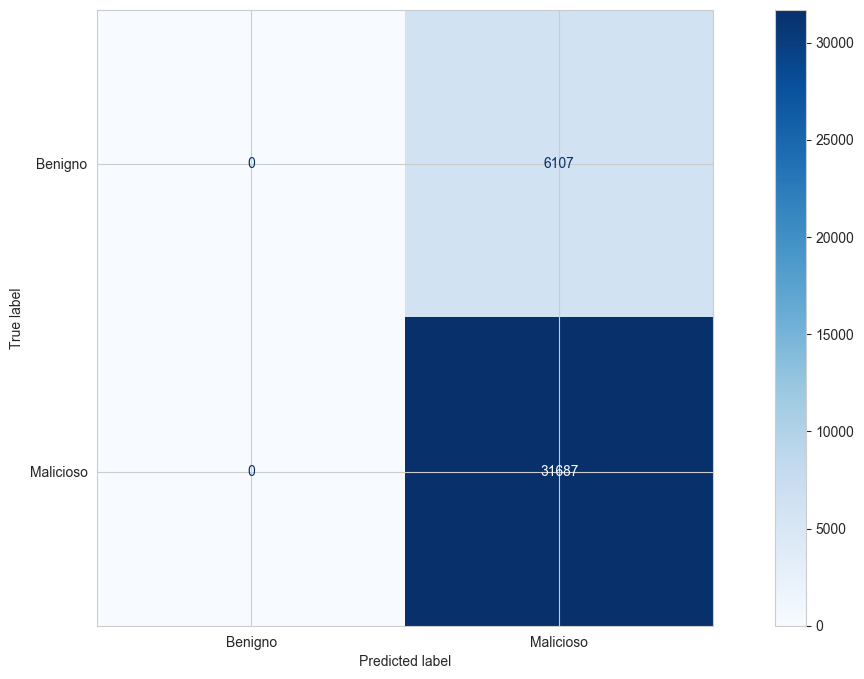

In [6]:
# --- Avaliação Final no Conjunto de Teste ---
print("Avaliando no conjunto de teste...")

# 1. Obter probabilidades no conjunto de teste
y_pred_probs_test = final_model.predict_proba(X_test_proc)[:, 1]

# 2. Encontrar o melhor limiar que maximiza o F1-Score da classe positiva
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_probs_test)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-9)
best_f1_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_f1_idx]
print(f"Melhor Limiar de Decisão encontrado no teste: {best_threshold:.4f}")

# 3. Aplicar o limiar otimizado
y_pred_tuned_test = (y_pred_probs_test >= best_threshold).astype(int)

# --- Relatório Final ---
print("\n--- Relatório de Classificação Final (com Limiar Otimizado) ---")
print(classification_report(y_test, y_pred_tuned_test, target_names=['Benigno (0)', 'Malicioso (1)']))

# Calcular ROC AUC
roc_auc = roc_auc_score(y_test, y_pred_probs_test)
print(f"\nROC AUC (Teste): {roc_auc:.4f}")

# --- Matriz de Confusão Final ---
print("\n--- Matriz de Confusão Final ---")
cm = confusion_matrix(y_test, y_pred_tuned_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Benigno', 'Malicioso'])
disp.plot(cmap=plt.cm.Blues)
plt.show()